<a href="https://colab.research.google.com/github/AlexKalll/Supervised-ML-Models/blob/main/Variational_Autoencoder_(VAE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda


100%|██████████| 170M/170M [00:12<00:00, 13.8MB/s]


Train samples: 50000, Test samples: 10000
Starting training...
Epoch 01, Loss: 110.7374
Epoch 02, Loss: 87.9494
Epoch 03, Loss: 84.4979
Epoch 04, Loss: 82.9083
Epoch 05, Loss: 82.0040
Epoch 06, Loss: 80.9152
Epoch 07, Loss: 80.4125
Epoch 08, Loss: 79.8041
Epoch 09, Loss: 79.5492
Epoch 10, Loss: 79.0475
Epoch 11, Loss: 78.8596
Epoch 12, Loss: 78.4698
Epoch 13, Loss: 78.2820
Epoch 14, Loss: 77.9682
Epoch 15, Loss: 77.7005
Epoch 16, Loss: 77.5601
Epoch 17, Loss: 77.4211
Epoch 18, Loss: 77.1864
Epoch 19, Loss: 77.0912
Epoch 20, Loss: 76.9466
Epoch 21, Loss: 76.8635
Epoch 22, Loss: 76.6442
Epoch 23, Loss: 76.6188
Epoch 24, Loss: 76.3974
Epoch 25, Loss: 76.4413
Epoch 26, Loss: 76.3221
Epoch 27, Loss: 76.1737
Epoch 28, Loss: 76.1603
Epoch 29, Loss: 76.0455
Epoch 30, Loss: 75.9438
Epoch 31, Loss: 75.8631
Epoch 32, Loss: 75.7254
Epoch 33, Loss: 75.7093
Epoch 34, Loss: 75.6766
Epoch 35, Loss: 75.6335
Epoch 36, Loss: 75.6108
Epoch 37, Loss: 75.4601
Epoch 38, Loss: 75.5057
Epoch 39, Loss: 75.4348


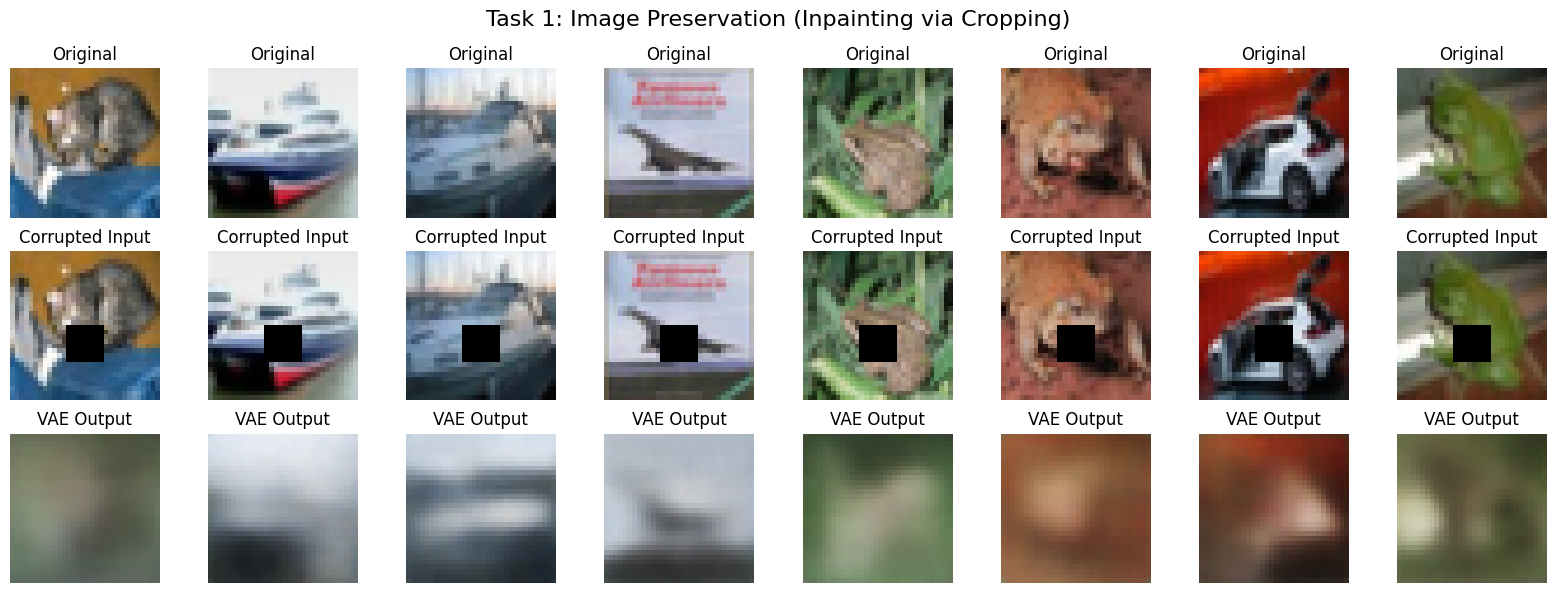


Evaluating Task 2: Generating new images...


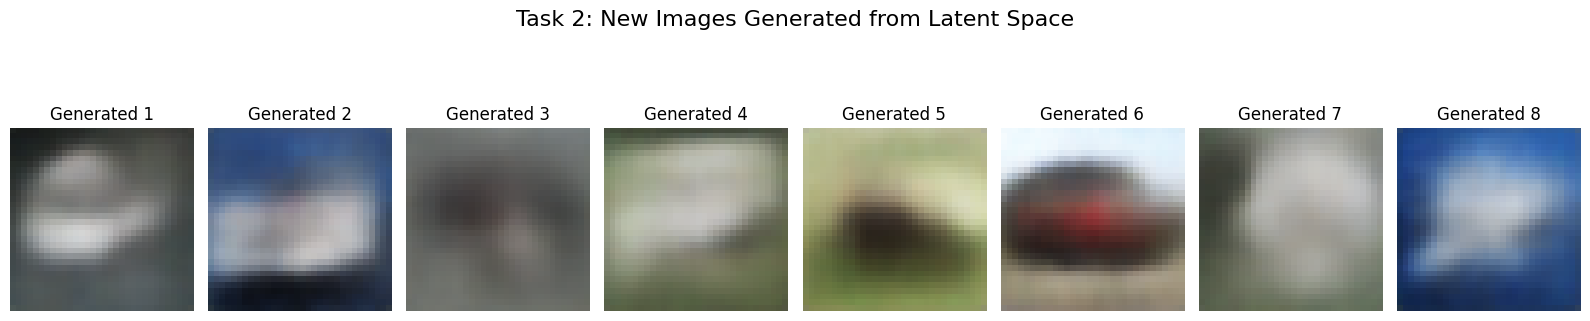


Model saved as 'vae_inpainting_cifar10.pth'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# 1. Custom Corruption: Crop (Structured Missing Data)
# -------------------------------
def crop_corruption(images, crop_size=8):
    """
    Simulates missing data by adding a black square patch.
    images: Tensor of shape (B, C, H, W)
    crop_size: Size of the square patch to remove.
    """
    corrupted = images.clone()
    _, _, h, w = images.shape
    # Random top-left corner for the crop
    y = np.random.randint(0, h - crop_size)
    x = np.random.randint(0, w - crop_size)
    corrupted[:, :, y:y+crop_size, x:x+crop_size] = 0.0
    return corrupted

# -------------------------------
# 2. VAE Model Definition (adjusted for 32x32 CIFAR-10 images)
# -------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # Encoder: 3x32x32 -> 256x2x2 feature map
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 32 -> 16
            nn.BatchNorm2d(32), # Add BatchNorm
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 16 -> 8
            nn.BatchNorm2d(64), # Add BatchNorm
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8 -> 4
            nn.BatchNorm2d(128), # Add BatchNorm
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), # 4 -> 2
            nn.BatchNorm2d(256), # Add BatchNorm
            nn.ReLU(),
            nn.Flatten()
        )

        # After 4 stride-2 convolutions on 32x32 input, we get 2x2 feature maps
        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)

        # Decoder input: latent -> feature map
        self.decoder_input = nn.Linear(latent_dim, 256 * 2 * 2)

        # Decoder: mirror of encoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 2 -> 4
            nn.BatchNorm2d(128), # Add BatchNorm
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 4 -> 8
            nn.BatchNorm2d(64), # Add BatchNorm
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 8 -> 16
            nn.BatchNorm2d(32), # Add BatchNorm
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 16 -> 32
            nn.Sigmoid()  # Output in [0,1] range
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 256, 2, 2)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# -------------------------------
# 3. Loss Function (ELBO)
# -------------------------------
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction Loss (MSE for image preservation)
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

# -------------------------------
# 4. Training Loop
# -------------------------------
def train(model, train_loader, optimizer, epochs=20):
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            # Apply corruption (CROP) - THIS IS TASK 1 SPECIFIC
            corrupted_data = crop_corruption(data, crop_size=8)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(corrupted_data)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

        avg_loss = train_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1:02d}, Loss: {avg_loss:.4f}')

# -------------------------------
# 5. Evaluation: Task 1 - Image Preservation (Inpainting)
# -------------------------------
def test_reconstruction(model, test_loader):
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        data = data.to(device)
        corrupted = crop_corruption(data, crop_size=8)
        recon, _, _ = model(corrupted)

        # Plot: Original | Corrupted (Input) | Reconstructed
        fig, axes = plt.subplots(3, 8, figsize=(16, 6))
        for i in range(8):
            # Original
            axes[0, i].imshow(data[i].cpu().permute(1,2,0))
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')

            # Corrupted (Model Input)
            axes[1, i].imshow(corrupted[i].cpu().permute(1,2,0))
            axes[1, i].set_title("Corrupted Input")
            axes[1, i].axis('off')

            # Reconstructed
            axes[2, i].imshow(recon[i].cpu().permute(1,2,0))
            axes[2, i].set_title("VAE Output")
            axes[2, i].axis('off')
        plt.suptitle("Task 1: Image Preservation (Inpainting via Cropping)", fontsize=16)
        plt.tight_layout()
        plt.show()

# -------------------------------
# 6. Evaluation: Task 2 - Generate New Images
# -------------------------------
def generate_new_samples(model, latent_dim, num_samples=8):
    """Generate images from random latent vectors."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        samples = model.decode(z)

        fig, axes = plt.subplots(1, num_samples, figsize=(16, 4))
        for i in range(num_samples):
            axes[i].imshow(samples[i].cpu().permute(1,2,0))
            axes[i].set_title(f"Generated {i+1}")
            axes[i].axis('off')
        plt.suptitle("Task 2: New Images Generated from Latent Space", fontsize=16)
        plt.tight_layout()
        plt.show()

# -------------------------------
# 7. Main Execution (Run Everything)
# -------------------------------
if __name__ == "__main__":
    # Hyperparameters
    BATCH_SIZE = 64
    LATENT_DIM = 256 # Increased latent dimension
    EPOCHS = 100 # Increased epochs for better convergence

    # Data Loading (CIFAR-10, 32x32 RGB images)
    print("Downloading CIFAR-10 dataset...")
    transform = transforms.Compose([
        transforms.ToTensor(),  # Converts to [0,1]
    ])

    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

    # Initialize model and optimizer
    model = VAE(latent_dim=LATENT_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Train the VAE
    print("Starting training...")
    train(model, train_loader, optimizer, epochs=EPOCHS)

    # Evaluate Task 1: Image Preservation
    print("\nEvaluating Task 1: Reconstruction of corrupted images...")
    test_reconstruction(model, test_loader)

    # Evaluate Task 2: Generative Sampling
    print("\nEvaluating Task 2: Generating new images...")
    generate_new_samples(model, LATENT_DIM)

    # Save model (optional)
    torch.save(model.state_dict(), "vae_inpainting_cifar10.pth")
    print("\nModel saved as 'vae_inpainting_cifar10.pth'")